# EFFECT OF OSCILLATIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Initializations

In [88]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [oscillation_df[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

,system_id,species_name,frequencies,endtime,key
37,BIOMD0000000042,GLC,[],300.0,BIOMD0000000042_GLC
39,BIOMD0000000042,FBP,[],300.0,BIOMD0000000042_FBP
40,BIOMD0000000042,GAP,[],300.0,BIOMD0000000042_GAP
41,BIOMD0000000042,NAD,[],300.0,BIOMD0000000042_NAD
42,BIOMD0000000042,NADH,[],300.0,BIOMD0000000042_NADH
...,...,...,...,...,...
1107209,BIOMD0000001059,sursmac,[],7000.0,BIOMD0000001059_sursmac
1107210,BIOMD0000001059,smacmit,[],7000.0,BIOMD0000001059_smacmit
1107211,BIOMD0000001059,smac,[],7000.0,BIOMD0000001059_smac
1107212,BIOMD0000001060,x1,[],40.0,BIOMD0000001060_x1


# Individual models

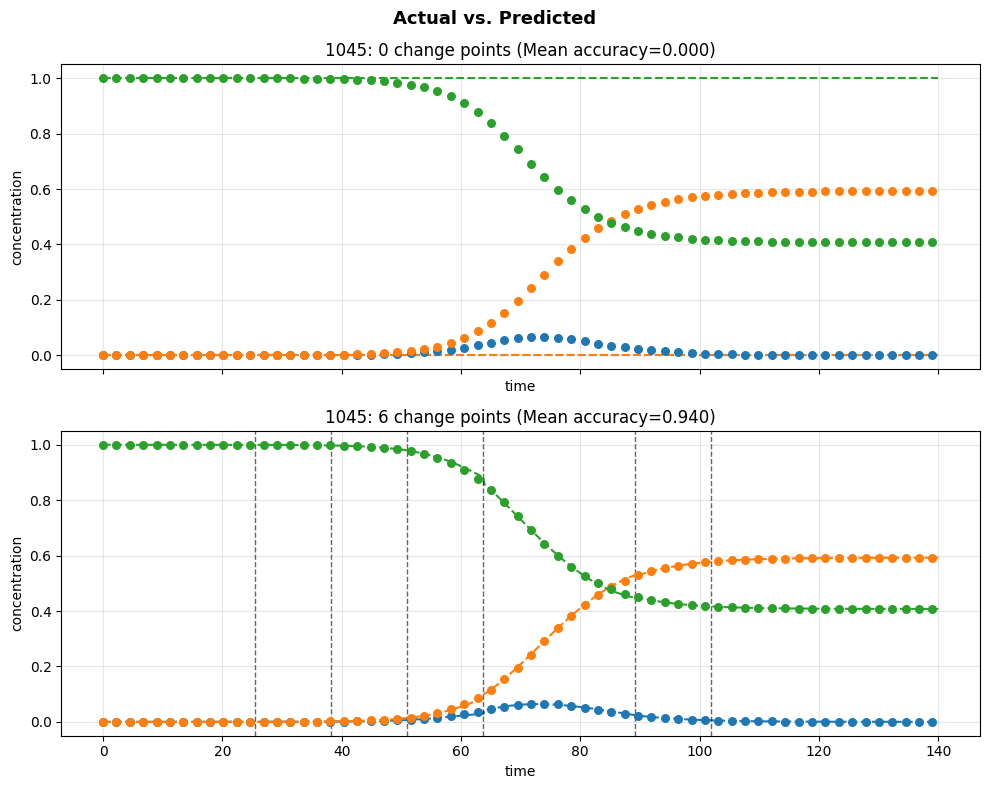

In [3]:
#for model_num in [45, 548, 551, 1045]:
for model_num in [1045]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        psd = PiecewiseSystemDiscovery(df, max_changepoint=10, min_segment_length=30,
                                        max_fractional_reduction=0.01, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# CDFs

## All Models

In [43]:
threshold = 0.001
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
DF = pd.read_csv(path)
DF.columns

Index(['system_id', 'aggregation_type', 'mean', 'min', 'max', 'count',
       'invalid_count', 'p05', 'p10', 'p20', 'p25', 'p30', 'p50', 'p80', 'p90',
       'p95', 'p99', 'a80', 'a90', 'a95', 'max_changepoint',
       'min_segment_length', 'max_fractional_reduction',
       'coefficient_threshold', 'num_changepoint'],
      dtype='str')

In [50]:
DF["max_changepoint"].unique()

array([ 0,  1,  5, 10, 12, 15, 17, 18, 19, 20])

In [30]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

13       1.000
14       1.000
15       1.000
59       1.000
60       0.801
         ...  
79219    1.000
79220    1.000
79221      NaN
79222      NaN
79223      NaN
Name: a80, Length: 7378, dtype: float64

In [133]:
def plotCDF(coefficient_threshold: float = 0.001, max_changepoints=[0, 1, 5, 10, 15, 19], is_species: bool = True, col="p10",
        is_non_oscillating: Optional[bool] = None):
    # Construct the dataframe to process
    path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}.csv")
    df = pd.read_csv(path)
    if is_non_oscillating:
        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
        #
        sel = df["key"].isin(NONOSCILLATION_DF["key"])
        df = df[sel]
    #
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    if is_species:
        length = np.sum((df[cn.COL_AGGREGATION_TYPE] != "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0))
    else:
        length = np.sum((df[cn.COL_AGGREGATION_TYPE] == "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0))
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold})")

In [139]:
df = DF
sel = (df[cn.COL_AGGREGATION_TYPE] == "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
df[sel]

,system_id,aggregation_type,mean,min,max,count,invalid_count,p05,p10,p20,...,p95,p99,a80,a90,a95,max_changepoint,min_segment_length,max_fractional_reduction,coefficient_threshold,num_changepoint
0,BIOMD0000000003,model,0.427663,0.000000,0.999977,3,0,0.028301,0.056602,0.113204,...,0.928280,0.985638,0.333333,0.333333,0.333333,0,50,0.01,0.001,0
40,BIOMD0000000004,model,0.427834,0.000000,0.990477,5,0,0.000000,0.000000,0.000000,...,0.989314,0.990244,0.400000,0.400000,0.400000,0,50,0.01,0.001,0
100,BIOMD0000000005,model,0.000000,0.000000,0.000000,6,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,50,0.01,0.001,0
170,BIOMD0000000008,model,1.000000,1.000000,1.000000,3,2,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0,50,0.01,0.001,0
230,BIOMD0000000010,model,0.000000,0.000000,0.000000,8,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,50,0.01,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78916,BIOMD0000001057,model,0.496758,0.000000,0.993515,2,0,0.049676,0.099352,0.198703,...,0.943839,0.983580,0.500000,0.500000,0.500000,0,50,0.01,0.001,0
78946,BIOMD0000001058,model,0.056710,0.000000,0.567099,10,0,0.000000,0.000000,0.000000,...,0.311904,0.516060,0.000000,0.000000,0.000000,0,50,0.01,0.001,0
79056,BIOMD0000001059,model,0.507240,0.000000,1.000000,8,2,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.250000,0.250000,0.250000,0,50,0.01,0.001,0
79166,BIOMD0000001060,model,0.446057,0.146734,0.745381,2,0,0.176666,0.206598,0.266463,...,0.715448,0.739394,0.000000,0.000000,0.000000,0,50,0.01,0.001,0


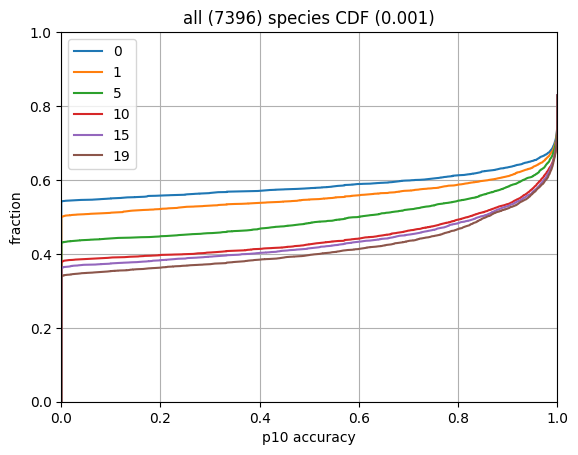

In [132]:
plotCDF(coefficient_threshold=0.001, is_species=True)

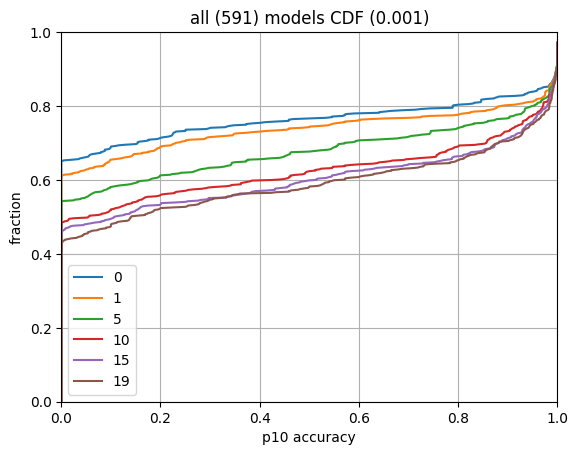

In [134]:
plotCDF(coefficient_threshold=0.001, is_species=False)

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

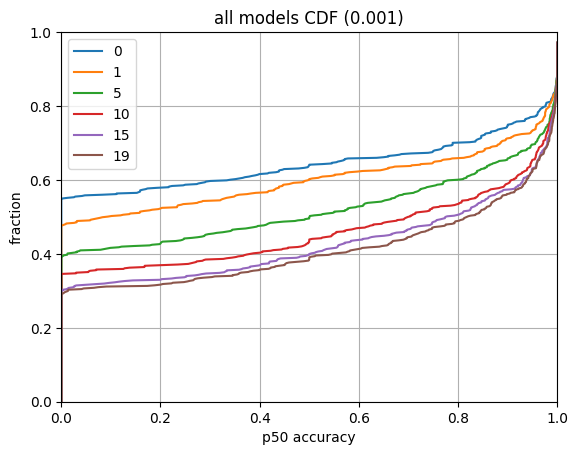

In [105]:
plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

## Oscillating vs. Non-Oscillating Models

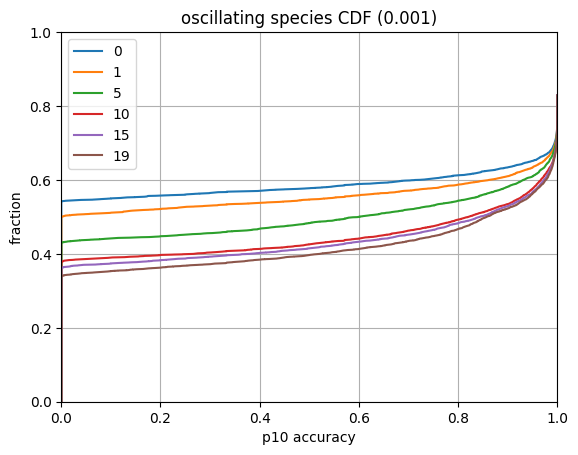

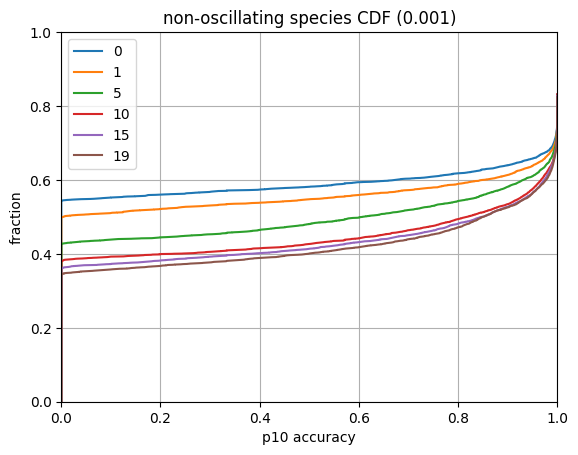

In [107]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)